# Homework 2: Machine Learning for Regression

DataTalks.Club Machine Learning Zoomcamp 2026

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/workspaces/mlbookcamp-code/cohorts/2026/data/car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## Dataset preparation

Keep only the columns used for the regression model.

In [2]:
COLUMNS = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[COLUMNS].copy()
df.shape

(10000, 5)

## EDA

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

In [3]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

<Axes: >

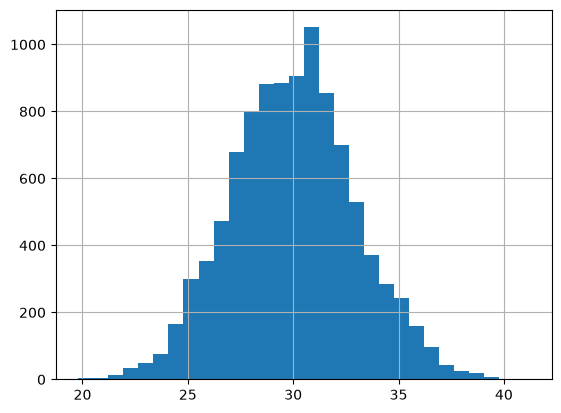

In [4]:
df['fuel_efficiency_mpg'].hist(bins=30)

## Question 1

There's one column with missing values. What is it?

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
# Answer: 'horsepower'

## Question 2

What's the median (50% percentile) for variable 'horsepower'?

In [7]:
df['horsepower'].median()

np.float64(254.0)

In [8]:
# Answer: 254

## Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture.

In [9]:
def split_dataset(data, seed):
    n = len(data)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = data.iloc[idx[:n_train]]
    df_val = data.iloc[idx[n_train:n_train + n_val]]
    df_test = data.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

In [10]:
df_train, df_val, df_test = split_dataset(df, seed=42)
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Linear regression helper

Train a linear regression model using the normal equations, as in the lessons.

In [11]:
def linear_weights(x, y, regularization=0.0):
    matrix = np.column_stack([np.ones(len(x)), x.to_numpy(dtype=float)])
    xtx = matrix.T @ matrix
    reg = regularization * np.eye(xtx.shape[0])
    reg[0, 0] = 0.0  # do not regularize the bias term
    return np.linalg.solve(xtx + reg, matrix.T @ y.to_numpy(dtype=float))


def linear_rmse(train_x, train_y, val_x, val_y, fill_value, regularization=0.0):
    train_filled = train_x.fillna(fill_value)
    val_filled = val_x.fillna(fill_value)
    weights = linear_weights(train_filled, train_y, regularization)
    matrix = np.column_stack([np.ones(len(val_filled)), val_filled.to_numpy(dtype=float)])
    predictions = matrix @ weights
    return float(np.sqrt(np.mean((val_y.to_numpy(dtype=float) - predictions) ** 2)))

## Question 3

Fill the NAs for the column from Q1 ('horsepower') with 0 or with the mean
(computed on the training set only). Which option gives better RMSE?

In [12]:
X_train = df_train[COLUMNS[:-1]]
y_train = df_train['fuel_efficiency_mpg']
X_val = df_val[COLUMNS[:-1]]
y_val = df_val['fuel_efficiency_mpg']

rmse_zero = linear_rmse(X_train, y_train, X_val, y_val, fill_value=0.0)
rmse_mean = linear_rmse(X_train, y_train, X_val, y_val, fill_value=X_train['horsepower'].mean())

rmse_zero, round(rmse_zero, 3), rmse_mean, round(rmse_mean, 3)

(2.205293194751563, 2.205, 2.2018174845685805, 2.202)

In [13]:
# Answer: With mean

## Question 4

Fill the NAs with 0 and try different values of r. Which r gives the best RMSE?

In [14]:
regularization_values = [0, 0.01, 0.1, 1, 5, 10, 100]
regularization_scores = {
    r: linear_rmse(X_train, y_train, X_val, y_val, fill_value=0.0, regularization=r)
    for r in regularization_values
}
for r, score in regularization_scores.items():
    print(f"r={r:>6}: RMSE={round(score, 4)}")

best_r = min(regularization_values, key=lambda r: (round(regularization_scores[r], 4), r))
best_r

r=     0: RMSE=2.2053
r=  0.01: RMSE=2.2053
r=   0.1: RMSE=2.2053
r=     1: RMSE=2.2053
r=     5: RMSE=2.2053
r=    10: RMSE=2.2053
r=   100: RMSE=2.2053


0

In [15]:
# Answer: 0

## Question 5

Try different seed values [0..9], fill NAs with 0, train without regularization,
and compute the standard deviation of the validation RMSE scores.

In [16]:
seed_scores = []
for seed in range(10):
    seed_train, seed_val, _ = split_dataset(df, seed=seed)
    score = linear_rmse(
        seed_train[COLUMNS[:-1]], seed_train['fuel_efficiency_mpg'],
        seed_val[COLUMNS[:-1]], seed_val['fuel_efficiency_mpg'],
        fill_value=0.0,
    )
    seed_scores.append(score)
    print(f"seed={seed}: RMSE={round(score, 4)}")

std = np.std(seed_scores)
round(std, 3)

seed=0: RMSE=2.2392
seed=1: RMSE=2.2021
seed=2: RMSE=2.1634
seed=3: RMSE=2.2044
seed=4: RMSE=2.2019
seed=5: RMSE=2.2458
seed=6: RMSE=2.2697
seed=7: RMSE=2.1908
seed=8: RMSE=2.2166
seed=9: RMSE=2.207


np.float64(0.029)

In [17]:
# Answer: 0.029

## Question 6

Split with seed 9, combine train and validation, fill NAs with 0, train with
r=0.001, and evaluate on the test dataset.

In [18]:
train_9, val_9, test_9 = split_dataset(df, seed=9)
combined = pd.concat([train_9, val_9])

test_rmse = linear_rmse(
    combined[COLUMNS[:-1]], combined['fuel_efficiency_mpg'],
    test_9[COLUMNS[:-1]], test_9['fuel_efficiency_mpg'],
    fill_value=0.0, regularization=0.001,
)
test_rmse, round(test_rmse, 3)

(2.2357747028137993, 2.236)

In [19]:
# Answer: 2.236

## Summary of answers

1. Missing values column: `horsepower`
2. Median horsepower: 254
3. Better imputation: With mean
4. Best regularization: 0
5. RMSE standard deviation: 0.029
6. Test RMSE (seed 9, r=0.001): 2.236